# 03 · MNIST final training

Notebook này đọc thư mục dataset, train bốn model, lưu file weight và đánh giá trên validation/test.

In [1]:
from pathlib import Path
import sys
import json
from time import perf_counter
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from gk.web.backend.digits_config import (
    DATASET_DIR, DATASET_PATH, MODEL_ARTIFACT_PATH, MODEL_CONFIG_PATH, RAW_DATASET_PATH,
    PIXEL_COUNT, PIXEL_SIZE, SPLIT_PATH, WEIGHTS_PATH,
)
from gk.web.backend.digits_models import build_logistic, build_mlp, export_layers, model_metadata
from gk.web.backend.digits_augmentation import build_augmented_variants, repeat_labels
from gk.web.backend.model_config import (
    AUGMENT_FACTOR, AUGMENT_SCALE_RANGE, AUGMENT_SHIFT_PIXELS,
    AUGMENT_STROKE_VARIANTS, AUGMENT_TRAINING,
)

CONFIG_PATH = MODEL_CONFIG_PATH
OUTPUT_PATH = WEIGHTS_PATH
TRAIN_LOG_PATH = DATASET_DIR / 'training_log.json'
WEB_OUTPUT_PATH = MODEL_ARTIFACT_PATH
print('Configured input:', f'{PIXEL_SIZE}x{PIXEL_SIZE} ({PIXEL_COUNT} features)')
data = np.load(DATASET_PATH)
raw_data = np.load(RAW_DATASET_PATH)
if not CONFIG_PATH.exists():
    raise FileNotFoundError(f'Run mnist_models.ipynb first to create {CONFIG_PATH}')
config = json.loads(CONFIG_PATH.read_text(encoding='utf-8'))
X_train_images = data['X_train_pixels'].astype(float)
y_train = data['y_train'].astype(int)
X_test_images = data['X_test_pixels'].astype(float)
y_test = data['y_test'].astype(int)
X_train_pixels = X_train_images.reshape(len(X_train_images), -1)
X_test_pixels = X_test_images.reshape(len(X_test_images), -1)
split = json.loads(SPLIT_PATH.read_text(encoding='utf-8'))
fit_indices = np.asarray(split['fit_indices'], dtype=int)
validation_indices = np.asarray(split['validation_indices'], dtype=int)
raw_train_images = raw_data['X_train_images'].astype(float)
original_fit_pixels = X_train_pixels[fit_indices]
original_fit_labels = y_train[fit_indices]
if AUGMENT_TRAINING:
    augmented_pixels = build_augmented_variants(
        raw_train_images[fit_indices],
        factor=AUGMENT_FACTOR,
        shift_pixels=AUGMENT_SHIFT_PIXELS,
        stroke_variants=AUGMENT_STROKE_VARIANTS,
        scale_range=AUGMENT_SCALE_RANGE,
        seed=config['random_seed'],
    )
    fit_pixels = np.vstack((original_fit_pixels, augmented_pixels))
    y_fit = repeat_labels(original_fit_labels, AUGMENT_FACTOR)
else:
    augmented_pixels = np.empty((0, PIXEL_COUNT), dtype=np.float32)
    fit_pixels = original_fit_pixels
    y_fit = original_fit_labels
scaler = StandardScaler().fit(fit_pixels)
mean = scaler.mean_
std = scaler.scale_
config['scaler'] = {'mean': mean.tolist(), 'std': std.tolist()}
CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding='utf-8')
X_fit = scaler.transform(fit_pixels)
X_validation = scaler.transform(X_train_pixels[validation_indices])
X_test = scaler.transform(X_test_pixels)
y_validation = y_train[validation_indices]
print('Loaded dataset and model config')
print(f'augmentation: {len(original_fit_pixels)} originals + {len(augmented_pixels)} variants = {len(X_fit)} train samples')

Configured input: 16x16 (256 features)


Loaded dataset and model config
augmentation: 48000 originals + 96000 variants = 144000 train samples


## Train bốn model và ghi log

Các config ở đây đến từ `mnist_model_config.json`, vì vậy có thể tối ưu notebook model mà không sửa notebook train. Log bên dưới lấy trực tiếp từ object đã fit.

In [2]:
model_configs = config['models']
trained = {}
training_log = []

def fit_and_log(model_id, model, model_config, kind):
    print(f'\n[{len(training_log) + 1}/4] {model_id} · training')
    print('    config:', model_config)
    started = perf_counter()
    model.fit(X_fit, y_fit)
    elapsed = perf_counter() - started
    loss_curve = [float(value) for value in getattr(model, 'loss_curve_', [])]
    iterations = int(np.max(model.n_iter_)) if hasattr(model, 'n_iter_') else None
    max_iter = int(model_config.get('max_iter', iterations or 0))
    converged = iterations is None or iterations < max_iter
    record = {
        'model_id': model_id, 'kind': kind, 'status': 'completed',
        'elapsed_seconds': round(elapsed, 3),
        'iterations': iterations, 'epochs': len(loss_curve) or None,
        'initial_loss': loss_curve[0] if loss_curve else None,
        'final_loss': loss_curve[-1] if loss_curve else None,
        'loss_curve': loss_curve, 'converged': converged,
        'config': model_config,
    }
    training_log.append(record)
    print(f'    done in {elapsed:.2f}s · iterations={iterations} · epochs={record["epochs"]} · final_loss={record["final_loss"]} · status={"converged" if converged else "max_iter reached"}')
    return model

logistic_config = model_configs['logistic']
trained['logistic'] = fit_and_log(
    'logistic',
    build_logistic(logistic_config['C'], logistic_config.get('solver', 'lbfgs'), logistic_config.get('max_iter', 2000), verbose=1),
    logistic_config, 'linear',
)

for model_id in ('mlp_4_one_layer', 'mlp_4_two_layers', 'compact_tuned'):
    model_config = model_configs[model_id]
    trained[model_id] = fit_and_log(
        model_id,
        build_mlp(
            tuple(model_config['hidden_layer_sizes']), model_config['activation'],
            model_config['learning_rate_init'], model_config['max_iter'],
            model_config.get('early_stopping', False), model_config.get('n_iter_no_change'),
            model_config.get('batch_size'), verbose=True,
        ),
        model_config, 'ann',
    )

print('trained:', list(trained))


[1/4] logistic · training
    config: {'kind': 'linear', 'C': 1.0, 'solver': 'lbfgs', 'max_iter': 300}


    done in 3.75s · iterations=126 · epochs=None · final_loss=None · status=converged

[2/4] mlp_4_one_layer · training
    config: {'kind': 'ann', 'hidden_layer_sizes': [8], 'activation': 'tanh', 'learning_rate_init': 0.001, 'batch_size': 256, 'max_iter': 350, 'early_stopping': False}
Iteration 1, loss = 1.03601148


Iteration 2, loss = 0.56552444
Iteration 3, loss = 0.47813425


Iteration 4, loss = 0.44138025
Iteration 5, loss = 0.41958184


Iteration 6, loss = 0.40483768
Iteration 7, loss = 0.39299212


...

Iteration 347, loss = 0.01596977


Iteration 348, loss = 0.01285464


Iteration 349, loss = 0.01709505


Iteration 350, loss = 0.01697189
    done in 136.27s · iterations=350 · epochs=350 · final_loss=0.01697188903576433 · status=max_iter reached
trained: ['logistic', 'mlp_4_one_layer', 'mlp_4_two_layers', 'compact_tuned']


/Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (350) reached and the optimization hasn't converged yet.
  warnings.warn(


In [3]:
results = {}
for model_id, model in trained.items():
    results[model_id] = {
        'validation_accuracy': accuracy_score(y_validation, model.predict(X_validation)),
        'test_accuracy': accuracy_score(y_test, model.predict(X_test)),
    }
    record = next(item for item in training_log if item['model_id'] == model_id)
    record.update(results[model_id])
    print(f'{model_id:24} validation={results[model_id]["validation_accuracy"]:.2%} test={results[model_id]["test_accuracy"]:.2%} elapsed={record["elapsed_seconds"]:.2f}s')
TRAIN_LOG_PATH.write_text(json.dumps({
    'dataset': str(DATASET_PATH), 'train_samples': len(X_fit),
    'original_train_samples': len(original_fit_pixels),
    'augmented_samples': len(augmented_pixels),
    'augmentation': {
        'enabled': AUGMENT_TRAINING, 'factor': AUGMENT_FACTOR,
        'shift_pixels': AUGMENT_SHIFT_PIXELS,
        'stroke_variants': AUGMENT_STROKE_VARIANTS,
        'scale_range': list(AUGMENT_SCALE_RANGE),
    },
    'validation_samples': len(X_validation), 'test_samples': len(X_test),
    'models': training_log,
}, indent=2), encoding='utf-8')
print('saved training log:', TRAIN_LOG_PATH)

logistic                 validation=90.09% test=90.76% elapsed=3.75s
mlp_4_one_layer          validation=91.37% test=91.56% elapsed=39.17s
mlp_4_two_layers         validation=91.90% test=92.64% elapsed=47.03s
compact_tuned            validation=96.90% test=96.70% elapsed=136.27s
saved training log: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/16x16/training_log.json


## Confusion matrix và loss curve

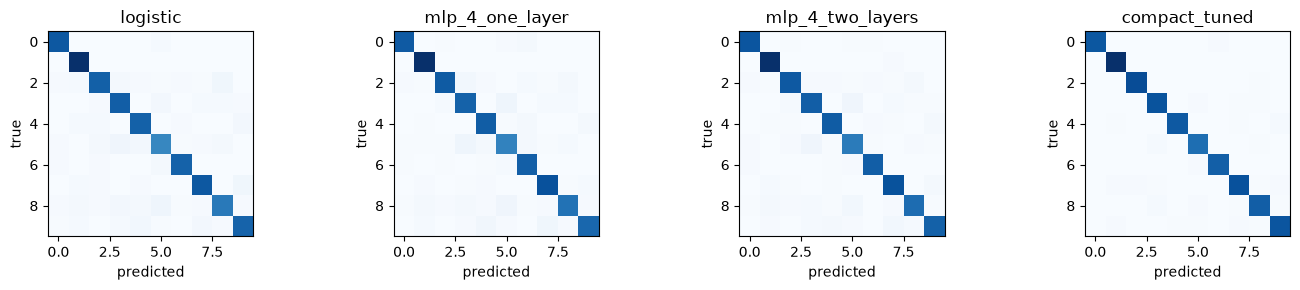

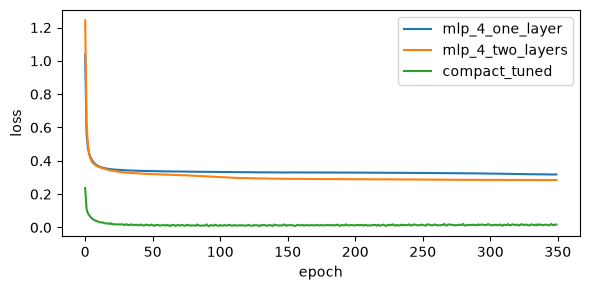

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for axis, (model_id, model) in zip(axes, trained.items()):
    matrix = confusion_matrix(y_test, model.predict(X_test), labels=np.arange(10))
    axis.imshow(matrix, cmap='Blues')
    axis.set_title(model_id)
    axis.set_xlabel('predicted')
    axis.set_ylabel('true')
plt.tight_layout()

plt.figure(figsize=(6, 3))
for model_id in ('mlp_4_one_layer', 'mlp_4_two_layers', 'compact_tuned'):
    model = trained[model_id]
    plt.plot(model.loss_curve_, label=model_id)
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.tight_layout()

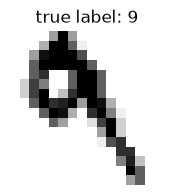

logistic → 4 66.97%
mlp_4_one_layer → 4 97.10%
mlp_4_two_layers → 4 97.55%
compact_tuned → 9 100.00%


In [5]:
sample_index = 7
plt.figure(figsize=(2, 2))
plt.imshow(X_test_pixels[sample_index].reshape(PIXEL_SIZE, PIXEL_SIZE), cmap='gray_r', vmin=0, vmax=16)
plt.title(f'true label: {y_test[sample_index]}')
plt.axis('off')
plt.show()
for model_id, model in trained.items():
    probabilities = model.predict_proba(X_test[sample_index:sample_index + 1])[0]
    print(model_id, '→', int(np.argmax(probabilities)), f'{probabilities.max():.2%}')

## Export artifact cho web

In [6]:
baseline_predictions = trained['logistic'].predict(X_test)
tuned_predictions = trained['compact_tuned'].predict(X_test)
demo_sample_index = 0
for index, baseline_prediction, tuned_prediction, target in zip(
    range(len(y_test)), baseline_predictions, tuned_predictions, y_test
):
    if baseline_prediction != target and tuned_prediction == target:
        demo_sample_index = int(index)
        break

def make_metadata(model_id, result_key, name, kind, model, architecture, activations, hidden_activation, source=None, source_url=None):
    return model_metadata(
        model_id, name, kind, model, architecture, activations,
        results[result_key]['test_accuracy'],
        results[result_key]['validation_accuracy'],
        hidden_activation, source, source_url,
    )

one_layer_hidden = list(model_configs['mlp_4_one_layer']['hidden_layer_sizes'])
two_layer_hidden = list(model_configs['mlp_4_two_layers']['hidden_layer_sizes'])
compact_config = model_configs['compact_tuned']
models = [
    make_metadata('logistic', 'logistic', 'Logistic Regression', 'linear', trained['logistic'], [PIXEL_COUNT, 10], [], None, 'scikit-learn LogisticRegression', 'https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html'),
    make_metadata('mlp-4-one-layer', 'mlp_4_one_layer', f'MLP · {one_layer_hidden[0]} neurons · 1 layer', 'ann', trained['mlp_4_one_layer'], [PIXEL_COUNT, *one_layer_hidden, 10], ['tanh'] * len(one_layer_hidden) + ['softmax'], model_configs['mlp_4_one_layer']['activation']),
    make_metadata('mlp-4-two-layer', 'mlp_4_two_layers', f'MLP · {two_layer_hidden[0]} neurons · 2 layers', 'ann', trained['mlp_4_two_layers'], [PIXEL_COUNT, *two_layer_hidden, 10], ['tanh'] * len(two_layer_hidden) + ['softmax'], model_configs['mlp_4_two_layers']['activation']),
    make_metadata('compact-tuned', 'compact_tuned', 'Compact tuned MLP', 'ann', trained['compact_tuned'], [PIXEL_COUNT, *compact_config['hidden_layer_sizes'], 10], [compact_config['activation']] * len(compact_config['hidden_layer_sizes']) + ['softmax'], compact_config['activation']),
]

artifact = {
    'version': 4,
    'random_seed': config['random_seed'],
    'pixel_size': PIXEL_SIZE,
    'dataset': {
        'name': 'MNIST handwritten digits',
        'description': f'Real handwritten digit images from MNIST, normalized to {PIXEL_SIZE}x{PIXEL_SIZE} grayscale pixels for this demo.',
        'sample_count': 70000, 'training_sample_count': 60000, 'test_sample_count': 10000,
        'input_shape': [PIXEL_SIZE, PIXEL_SIZE], 'feature_count': PIXEL_COUNT, 'class_count': 10,
        'pixel_min': 0, 'pixel_max': 16, 'original_input_shape': [28, 28],
        'source_url': 'https://yann.lecun.com/exdb/mnist/',
    },
    'preprocessing': {
        'name': f'CropSquareResize{PIXEL_SIZE} + StandardScaler',
        'feature_transform': f'denoise at 50% of max ink, keep largest component, crop foreground, resize to square, area-average resize to {PIXEL_SIZE}x{PIXEL_SIZE}, scale intensity to 0..16',
        'mean': mean.tolist(), 'std': std.tolist(),
    },
    'fit_indices': config['fit_indices'], 'validation_indices': config['validation_indices'],
    'test_indices': config['test_indices'],
    'test_samples': np.rint(X_test_pixels).astype(int).tolist(),
    'test_labels': y_test.astype(int).tolist(),
    'demo_sample_index': demo_sample_index,
    'augmentation': {
        'enabled': AUGMENT_TRAINING,
        'factor': AUGMENT_FACTOR,
        'source_count': int(len(original_fit_pixels)),
        'generated_count': int(len(X_fit)),
        'variant_count': int(len(augmented_pixels)),
        'shift_pixels': AUGMENT_SHIFT_PIXELS,
        'stroke_variants': AUGMENT_STROKE_VARIANTS,
        'scale_range': list(AUGMENT_SCALE_RANGE),
        'applied_to': 'fit split only; validation and test remain unchanged',
    },
    'baseline_tuning': {'rounds': config['search']['logistic_rounds'], 'C_candidates': [row['C'] for row in config['search']['logistic_candidates']], 'selected_C': model_configs['logistic']['C'], 'validation_accuracy': config['search']['selected_logistic_validation_accuracy']},
    'tuning': {'rounds': config['search']['mlp_rounds'], 'search_sample_count': config['search']['sample_count'], 'solver': 'adam', 'search_max_iter': 120, 'final_max_iter': compact_config['max_iter'], 'early_stopping': compact_config['early_stopping'], 'candidates': config['search']['mlp_candidates'], 'selected': compact_config['hidden_layer_sizes'], 'selected_activation': compact_config['activation'], 'selected_learning_rate_init': compact_config['learning_rate_init'], 'validation_accuracy': config['search']['selected_mlp_validation_accuracy']},
    'models': models,
}
serialized_artifact = json.dumps(artifact, indent=2)
OUTPUT_PATH.write_text(serialized_artifact, encoding='utf-8')
WEB_OUTPUT_PATH.write_text(serialized_artifact, encoding='utf-8')
print(f'Wrote weights: {OUTPUT_PATH}')
print(f'Updated web artifact: {WEB_OUTPUT_PATH}')

Wrote weights: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/16x16/mnist_weights.json
Updated web artifact: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/digits_models_16x16.json
